In [1]:
import cv2
import sqlite3
from matplotlib import pyplot as plt
import numpy as np
from operator import itemgetter
from numpy import linalg as LA
from visualize_model import Model
from database import blob_to_array, pair_id_to_image_ids

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 1. 3D mesh reconstruction from a set of images from the Gerrard Hall dataset.
Install Colmap and run the automatic reconstruction on the Gerrard Hall dataset

### Explanation
Following the steps from the slides of lab 4, this is the mesh I visualize in Meshlab, which is upside down. We can also see that the result has lots of outliers with points that are far away from the main cluster that form the structure of the building.

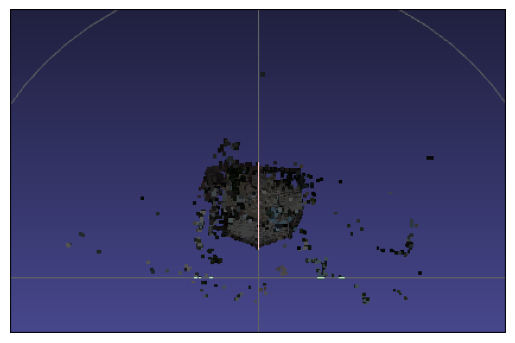

In [2]:
img = cv2.imread('images/default_gh_mesh.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

### Explanation
After some prunning and rotating the mesh in Meshlab, we are left with this mesh, which has a bounding box to better visualize the outliers prunning, as the bounding box better fit the main point cluster.

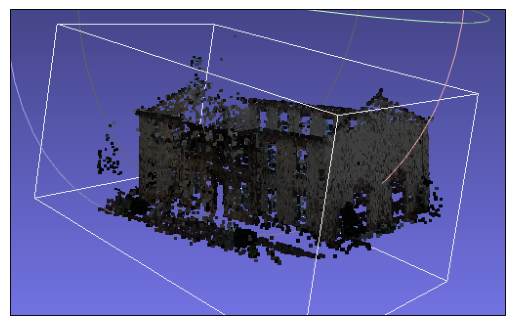

In [3]:
img = cv2.imread('images/prunned_gh_mesh.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

# 2. Analyze reconstructions using python
## 2.1. Run the notebook, using the Gerrard Hall reconstruction (0.5)
#### <span style='color:Green'> - Add the path to your reconstruction. Answer the questions at the end  </span>

In [4]:
# Add your path
reconstruction_path = "datasets/gerrard-hall/sparse/0"
database_path = "datasets/gerrard-hall/database.db"

#### Load an existing reconstruction and print its contents

In [5]:
model = Model()
model.read_model(reconstruction_path, ext='.bin') # Should also work with .txt

In [6]:
images = model.images
cameras = model.cameras
points3D = model.points3D

In [7]:
print(f"Loaded {len(images)} images. This is the information available for one of them:")
print(images[1])
print(f"\nLoaded {len(cameras)} cameras. This is the information available for one of them:")
print(cameras[1])
print(f"\nLoaded {len(points3D)} 3D points. This is the information available for one of them:")
print(points3D[1])

Loaded 100 images. This is the information available for one of them:
Image(id=1, qvec=array([ 0.63455801,  0.21772048, -0.2481694 ,  0.69881748]), tvec=array([-0.73281431, -1.95589521,  2.79273119]), camera_id=1, name='IMG_2387.JPG', xys=array([[ 758.38574219,   61.36777496],
       [2757.86962891,   11.28521633],
       [2775.62963867,   33.56768417],
       ...,
       [1864.0871582 , 3612.57421875],
       [2398.2121582 , 3603.64233398],
       [2398.2121582 , 3603.64233398]], shape=(12207, 2)), point3D_ids=array([-1, -1, -1, ..., -1, -1, -1], shape=(12207,)))

Loaded 1 cameras. This is the information available for one of them:
Camera(id=1, model='OPENCV', width=5616, height=3744, params=array([ 3.83803762e+03,  3.83702921e+03,  2.80800000e+03,  1.87200000e+03,
       -1.10258229e-01,  7.93837255e-02,  1.16927438e-04,  2.84732815e-04]))

Loaded 42794 3D points. This is the information available for one of them:
Point3D(id=1, xyz=array([-0.06389916, -1.5581926 , -1.62146962]), rgb=

#### Load the database

In [8]:
db = sqlite3.connect(database_path)

In [9]:
keypoints = dict(
        (image_id, blob_to_array(data, np.float32, (-1, 2)))
        for image_id, data in db.execute(
            "SELECT image_id, data FROM keypoints"))

In [10]:
print(f"Loaded keypoints from {len(keypoints)} images. These are the {len(keypoints[1])} keypoints for one of them:")
print(keypoints[1])

Loaded keypoints from 100 images. These are the 24414 keypoints for one of them:
[[7.5838574e+02 6.1367775e+01]
 [4.0777049e+00 2.3697526e+00]
 [2.7578696e+03 1.1285216e+01]
 ...
 [4.2930962e+01 4.8993421e+00]
 [2.3982122e+03 3.6036423e+03]
 [4.2930962e+01 2.5109098e+00]]


In [11]:
matches = dict()
count_no_data = 0
for pair_id, data in db.execute("SELECT pair_id, data FROM matches"):
    if data is None:
        count_no_data += 1
    else:
        matches[pair_id_to_image_ids(pair_id)] = blob_to_array(data, np.uint32, (-1, 2))
print(f"Loaded {len(matches)} matches. {count_no_data}/{len(matches)+count_no_data} matches contained no data")

Loaded 2153 matches. 2797/4950 matches contained no data


In [12]:
print("These are the matches between two images:")
print(matches[1,3])

These are the matches between two images:
[[1459   68]
 [8054  481]
 [8113  482]
 [8114  483]
 [8187  484]
 [6590  512]
 [8009  603]
 [8053  608]
 [8184  611]
 [8111  612]
 [8112  613]
 [8052  774]
 [8182  775]
 [8181  777]
 [5326  783]
 [5806  797]
 [8005  903]
 [8107  907]
 [8110  909]
 [8048  910]
 [8049  911]
 [8180  914]
 [8177  915]
 [8175  916]
 [5067  917]
 [8178  919]
 [5800  926]
 [6416  939]
 [8002 1041]
 [8000 1043]
 [8001 1044]
 [8044 1050]
 [5684 1062]
 [7995 1191]
 [8104 1192]
 [8099 1194]
 [8097 1196]
 [8100 1197]
 [8096 1198]
 [8169 1200]
 [8171 1201]
 [6658 1223]
 [8039 1339]
 [8092 1340]
 [8088 1341]
 [8094 1342]
 [8168 1343]
 [6477 1384]
 [7172 1397]
 [7173 1398]
 [7170 1399]
 [7168 1400]
 [7994 1491]
 [7991 1492]
 [7992 1493]
 [8036 1496]
 [7993 1498]
 [8087 1505]
 [5912 1525]
 [7003 1549]
 [7002 1550]
 [7986 1684]
 [8032 1685]
 [8165 1687]
 [8163 1688]
 [6570 1709]
 [6565 1710]
 [7237 1735]
 [8033 1855]
 [8031 1856]
 [8086 1857]
 [8085 1858]
 [8162 1860]
 [5436 18

#### Visualize the point cloud and cameras

In [13]:
model.create_window()
model.add_points()
model.add_cameras(scale=0.25)
model.show()

#### <span style='color:Green'>  How many keypoints there are in total? </span> 

In [14]:
count_total = 0
for key_array in keypoints.values():
    count_total += key_array.shape[0]

print(f"There are a total of {count_total} keypoints across all images in the dataset.")

There are a total of 2123400 keypoints across all images in the dataset.


#### <span style='color:Green'>  How many 3D points originated from a keypoint in the first image? </span>


In [15]:
count_first_image = [1 for p in points3D.values() if 1 in p.image_ids]
print(f"There are {len(count_first_image)} 3D points originated from a keypoint in the first image.")

There are 2824 3D points originated from a keypoint in the first image.


## 2.2 Plot the 3D points coloured according to the number of images and error. (0.5)

#### <span style='color:Green'> - Plot the 3D points coloured according to the **number of images** from which it originated. </span> Can you extract any conclusions from the visualization? 

In [16]:
### TO DO 2.2
from plotly import graph_objects as go
import plotly.express as px

pts3d_coords = []
pts3d_num_images = []
pts3d_error = []
for p in points3D.values():
    pts3d_coords.append(p.xyz)
    pts3d_num_images.append(len(p.image_ids))
    pts3d_error.append(p.error)
pts3d_coords = np.stack(pts3d_coords, axis=1)
pts3d_num_images = np.array(pts3d_num_images)
pts3d_num_images_normalized = pts3d_num_images / pts3d_num_images.max()
pts3d_error = np.array(pts3d_error)

fig = px.scatter_3d(x=pts3d_coords[0], y=pts3d_coords[1], z=pts3d_coords[2], color=pts3d_num_images, size=pts3d_num_images, opacity=1.0)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

### Explanation
From the visualization we can conclude that outliers are points that are seen by very few images, while more correct points from the facade of the building are seen by multiple images, up to 25 images. We also notice that accurate regions with neighbour points seen by less images tend to be more sparse and have parts of the building torn off.

#### <span style='color:Green'> - Plot the 3D points coloured according to the **error**. </span> - What is this parameter? Can you extract any conclusions from the visualization?

In [17]:
### TO DO 2.2
fig = px.scatter_3d(x=pts3d_coords[0], y=pts3d_coords[1], z=pts3d_coords[2], color=pts3d_error, size=pts3d_error, opacity=1.0)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

### Explanation
We couldn't find any clear definition on what the error computed by COLMAP is, but our guess is it represents the average reprojection error of a 3D point to all its original images. We can see from the visualization that points with this error are everywhere, and stand out more in outlier points. We conclude that we cannot use this measure as a correct depiction of the 3D reconstruction error due to some outliers having low error and some inliers having high error. 

## 2.3 Plot the 3D points that correspond to a keypoint in the first image. Also plot the image with the keypoints (1.0)


In [18]:
### TO DO 2.3
pts3d_image1 = []
for p in points3D.values():
    if 1 in p.image_ids:
        pts3d_image1.append(p.xyz)
pts3d_image1 = np.stack(pts3d_image1, axis=1)

fig = go.Figure(layout=dict(height=400, width=550))
fig.add_trace(go.Scatter3d(x=pts3d_image1[0], y=pts3d_image1[1], z=pts3d_image1[2], mode='markers', marker=dict(size=2, color="black", opacity=0.5)))
fig.show()
# fig = px.scatter_3d(x=pts3d_image1[0], y=pts3d_image1[1], z=pts3d_image1[2], size=np.ones_like(pts3d_image1[0]) * 0.5, opacity=1.0)
# fig.show()

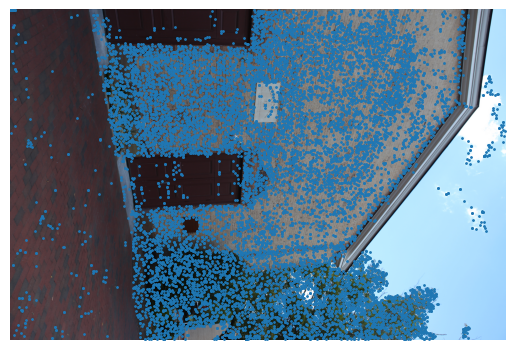

In [19]:
img = cv2.imread(f"datasets/gerrard-hall/images/{images[1].name}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.scatter(keypoints[1][:, 0], keypoints[1][:, 1], s=1)
plt.axis('off')
plt.show()

## 2.4 Create a visualization for the number of matches between all images. (1.0)
For example: https://seaborn.pydata.org/generated/seaborn.heatmap.html

<Axes: >

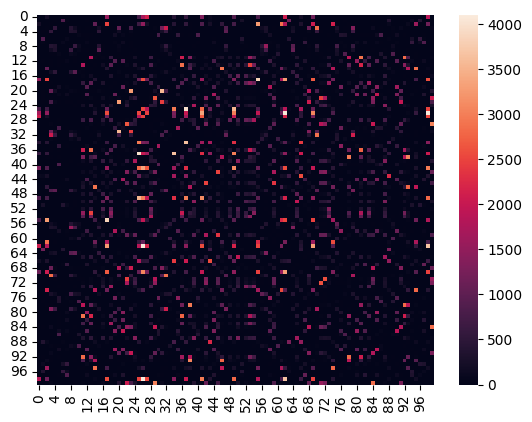

In [20]:
### TO DO 2.4
import seaborn as sns

match_array = np.zeros((101, 101))
for k, m in matches.items():
    match_array[k[0], k[1]] = len(m)
    match_array[k[1], k[0]] = len(m)


sns.heatmap(match_array[1:, 1:])

## 2.5 Visualize the keypoints and matches between the two images used in lab 3 using Colmap, how it compares to the results from lab 3? (1.0)
#### <span style='color:Green'> You can use the GUI to get the keypoints and matches and then visualize it here, following the same style as in lab 3 to get comparable results. </span>

### Explanation
Instead of using the same method as in lab3, we use COLMAP's matches visualization, which is similar to lab3's method. In COLMAP'S visualization, keypoints without matches are shown as well, so we will only focus on the matching lines.

Comparing both methods, we see that COLMAP's method has more matches than the method from lab3. Not only it has more dense matches, but it also has matches in regions that we didn't detect as matches before, such as the left and right parts of the facades.

In [21]:
def fundamental_matrix(points1, points2):

    def _to_homogeneous(pts):
        pts = np.asarray(pts, dtype=np.float64)

        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # likely (2,N) or (3,N)
            pts = pts.T

        if pts.shape[1] == 2:
            ones = np.ones((pts.shape[0], 1), dtype=np.float64)
            pts_h = np.hstack([pts, ones])
            return pts_h

        if pts.shape[1] == 3:
            return pts

    def _normalize_points(pts_h):
        """
        Hartley-style normalization:
        - Translate so centroid is at origin
        - Scale so mean squared distance to origin is 1 (as stated in the slides)
        Returns:
            pts_n: normalized points (N,3)
            H: normalization transform (3,3) such that pts_n ~ H @ pts_h^T
        """
        pts_h = np.asarray(pts_h, dtype=np.float64)

        # Dehomogenize safely for centroid/scale computation
        w = pts_h[:, 2:3]
        w_safe = np.where(np.abs(w) < 1e-12, 1e-12, w)
        pts_e = pts_h[:, 0:2] / w_safe  # (N,2)

        centroid = np.mean(pts_e, axis=0)  # (cx, cy)

        d = pts_e - centroid  # (N,2)
        msd = np.mean(np.sum(d**2, axis=1))  # mean squared distance

        if msd < 1e-12:
            s = 1.0
        else:
            s = 1.0 / np.sqrt(msd)

        cx, cy = centroid
        H = np.array([
            [s, 0.0, -s * cx],
            [0.0, s, -s * cy],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)

        pts_n = (H @ pts_h.T).T  # (N,3)
        return pts_n, H


    # 0. Convert to homogeneous if necessary
    p1 = _to_homogeneous(points1)
    p2 = _to_homogeneous(points2)

    # 1. Normalize points
    q1, H1 = _normalize_points(p1)
    q2, H2 = _normalize_points(p2)

    # Dehomogenize normalized points for W construction
    q1 = q1 / np.where(np.abs(q1[:, 2:3]) < 1e-12, 1e-12, q1[:, 2:3])
    q2 = q2 / np.where(np.abs(q2[:, 2:3]) < 1e-12, 1e-12, q2[:, 2:3])

    u  = q1[:, 0]
    v  = q1[:, 1]
    up = q2[:, 0]
    vp = q2[:, 1]

    # 2. Build W (Nx9)
    #    row = [u'*u, u'*v, u', v'*u, v'*v, v', u, v, 1]
    W = np.column_stack([
        up * u,  up * v,  up,
        vp * u,  vp * v,  vp,
        u,       v,       np.ones_like(u)
    ])

    # 3. SVD(W) -> f is last column of V
    Uw, Sw, Vtw = np.linalg.svd(W, full_matrices=True)
    f = Vtw[-1, :]  # last row of V^T = last column of V

    # 4. Compose F_rank3 (3x3)
    F_rank3 = f.reshape(3, 3)

    # 5-7. Enforce rank-2 constraint on F (SVD, zero last singular value)
    Uf, Sf, Vtf = np.linalg.svd(F_rank3)
    Sf[2] = 0.0
    F_rank2 = Uf @ np.diag(Sf) @ Vtf

    # 8. De-normalize: F = H2^T * F_rank2 * H1
    F = H2.T @ F_rank2 @ H1

    return F


def Ransac_fundamental_matrix(points1, points2, th, max_it_0):
    """
    Args:
        points1: points in image 1
        points2: points in image 2
        th: threshold on Sampson error 
        max_it_0: user predefined number of iterations 

    Returns:
        F: (3,3) Fundamental matrix
        inliers: list of int indices of inlier correspondences
    """

    def _to_3xN(pts):
        pts = np.asarray(pts, dtype=np.float64)
        if pts.ndim != 2:
            raise ValueError("points must be a 2D array")

        # If it's 2xN or 3xN, keep; if it's Nx2 or Nx3, transpose
        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # 2xN or 3xN
            pass
        else:
            # likely Nx2 or Nx3
            pts = pts.T

        if pts.shape[0] == 2:
            pts = np.vstack([pts, np.ones((1, pts.shape[1]), dtype=np.float64)])
        elif pts.shape[0] != 3:
            raise ValueError("points must be (2,N)/(3,N) or (N,2)/(N,3)")

        return pts  

    def _sampson_error(F, x1_3xN, x2_3xN, eps=1e-12):
        """
        Sampson error (PDF):
            (x2^T F x1)^2 / ( (Fx1)_1^2 + (Fx1)_2^2 + (F^T x2)_1^2 + (F^T x2)_2^2 )
        Returns: (N,) array
        """
        Fx1 = F @ x1_3xN          # 3xN
        Ftx2 = F.T @ x2_3xN       # 3xN
        x2tFx1 = np.sum(x2_3xN * Fx1, axis=0)  # (N,)

        denom = Fx1[0, :]**2 + Fx1[1, :]**2 + Ftx2[0, :]**2 + Ftx2[1, :]**2
        denom = np.maximum(denom, eps)

        return (x2tFx1**2) / denom

    # 1.Prepare points as 3xN 
    x1 = _to_3xN(points1)
    x2 = _to_3xN(points2)

    if x1.shape[1] != x2.shape[1]:
        raise ValueError("points1 and points2 must have same number of correspondences")

    N = x1.shape[1]
    if N < 8:
        raise ValueError("Need at least 8 correspondences")

    # 2.RANSAC params 
    s = 8
    p_success = 0.99
    th = float(th)

    rng = np.random.default_rng()

    best_F = None
    best_inliers_idx = np.array([], dtype=int)
    best_count = 0

    it = 0
    max_it = int(max_it_0)

    # 3.RANSAC loop 
    while it < max_it:
        idx = rng.choice(N, size=s, replace=False)

        try:
            F_cand = fundamental_matrix(x1[:, idx].T, x2[:, idx].T)  # pass as Nx3 (8x3)
        except Exception:
            it += 1
            continue

        # Compute Sampson error for all correspondences
        err = _sampson_error(F_cand, x1, x2)

        inliers_idx = np.where(err < th)[0]
        count = int(inliers_idx.size)

        if count > best_count:
            best_count = count
            best_inliers_idx = inliers_idx
            best_F = F_cand

            # Update estimated iterations (ensure 0.99 prob. of all-inlier sample)
            w = best_count / float(N)
            w = np.clip(w, 0.0, 1.0)

            if w >= 1.0 - 1e-12:
                N_est = 1.0
            else:
                denom = 1.0 - (w ** s)
                denom = np.clip(denom, 1e-12, 1.0 - 1e-12)
                N_est = np.log(1.0 - p_success) / np.log(denom)
                if not np.isfinite(N_est):
                    N_est = float(max_it_0)

            # maximum between user max and estimated max
            max_it = int(np.ceil(max(float(max_it_0), float(N_est))))

            # Safety cap to avoid absurd iteration counts 
            max_it = min(max_it, 200000)

        it += 1

    # 4.Refit with best inliers 
    if best_F is None or best_count < 8:
        F_all = fundamental_matrix(x1.T, x2.T)
        err_all = _sampson_error(F_all, x1, x2)
        inl_all = np.where(err_all < th)[0].astype(int).tolist()
        return F_all, inl_all

    # 5.Refine F with all inliers and recompute inliers once
    F_ref = fundamental_matrix(x1[:, best_inliers_idx].T, x2[:, best_inliers_idx].T)
    err_ref = _sampson_error(F_ref, x1, x2)
    inliers_ref = np.where(err_ref < th)[0].astype(int)

    return F_ref, inliers_ref.tolist()


Num matches lab3 method: 651


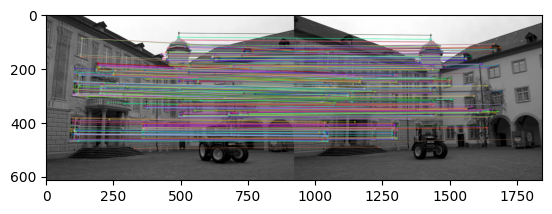

Num matches COLMAP method: 1687


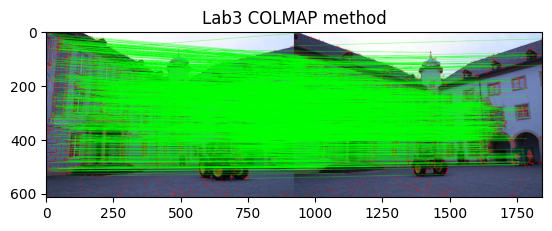

In [23]:
### TO DO 2.5
img1 = cv2.imread('datasets/lab3_imgs/images/0001_s.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('datasets/lab3_imgs/images/0002_s.png', cv2.IMREAD_GRAYSCALE)
h, w = img1.shape

# Initiate ORB detector
orb = cv2.ORB_create(3000)
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

# Keypoint matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1,des2)

# Robust estimation of the fundamental matrix #
points1 = []
points2 = []
for m in matches:
    points1.append([kp1[m.queryIdx].pt[0], kp1[m.queryIdx].pt[1], 1])
    points2.append([kp2[m.trainIdx].pt[0], kp2[m.trainIdx].pt[1], 1])
    
points1 = np.asarray(points1)
points1 = points1.T
points2 = np.asarray(points2)
points2 = points2.T

F, indices_inlier_matches = Ransac_fundamental_matrix(points1, points2, 1, 5000)
inlier_matches = itemgetter(*indices_inlier_matches)(matches)

print(f"Num matches lab3 method: {len(inlier_matches)}")
img_12 = cv2.drawMatches(img1,kp1,img2,kp2,inlier_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
fig = plt.figure()
plt.imshow(img_12)
plt.show()

img = cv2.imread("images/lab3_img12_matches_colmap.png", cv2.IMREAD_COLOR_RGB)
database_path = "datasets/lab3_imgs/database.db"
db = sqlite3.connect(database_path)

matches = dict()
count_no_data = 0
for pair_id, data in db.execute("SELECT pair_id, data FROM matches"):
    if data is None:
        count_no_data += 1
    else:
        matches[pair_id_to_image_ids(pair_id)] = blob_to_array(data, np.uint32, (-1, 2))

print(f"Num matches COLMAP method: {len(matches[1, 2])}")
plt.imshow(img)
plt.title("Lab3 COLMAP method")
plt.show()

## 2.6 Triangulate and visualize the 3D points from the keypoints extracted using Colmap on the two images used in lab 3, how it compares to the results from lab 3? (1.0) 
#### <span style='color:Green'> - Use the triangulation from lab 3 to the get the 3D points and visualize them following the same style. </span>

### Explanation
COLMAP cannot compute the sparse 3D reconstruction and thus, it does not provide the estimated camera poses with the P1 and P2 camera matrices. Therefore, we cannot use the triangulation method from lab3.

In [ ]:
# Write here the method for DLT triangulation
def triangulate(x1, x2, P1, P2, imsize) -> np.ndarray:
    assert P1.shape == (3,4) == P2.shape
    assert x1.shape == x2.shape and x1.shape[0] == 3
    '''
    Your implementation here
    '''
    # DLT approach
    # Step 0: Ensure homogeneous coordinates x1 and x2 have form of [x, y, 1]
    x1 = x1 / x1[2]
    x2 = x2 / x2[2]
    
    # Step 1: Normalize coordinates with matrix H
    H = np.array([
        [2 / imsize[1],      0,        -1],
        [     0,        2 / imsize[0], -1],
        [     0,             0,         1]
    ])
    x1_norm = H @ x1
    x2_norm = H @ x2
    P1_norm = H @ P1
    P2_norm = H @ P2

    # Step 2: Compute matrix A
    A = np.stack([
        x1_norm[0:1].T @ P1_norm[2:3] - P1_norm[0:1],
        x1_norm[1:2].T @ P1_norm[2:3] - P1_norm[1:2],
        x2_norm[0:1].T @ P2_norm[2:3] - P2_norm[0:1],
        x2_norm[1:2].T @ P2_norm[2:3] - P2_norm[1:2],
    ], axis=0).transpose(1, 0, 2) # Shape: 4 x n_points x 4 -> n_points x 4 x 4

    # Step 3: SVD decomposition to extract right null-vector (last column of V, last row of V transposed)
    _, _, Vh = LA.svd(A) 
    X_trian = Vh[:, -1] # Shape: n_points x 4
    return X_trian.T # Shape: 4 x n_points

def essential_from_fundamental(K, F):
    # Fundamental matrix F = K^-T @ E @ K^-1
    # Essential matris E =  K^T F @ K
    return K.T @ F @ K

In [ ]:
### TO DO 2.6
P1 = np.zeros((3,4))
P1[0,0]=P1[1,1]=P1[2,2]=1                            # Cam1 Canonical Camera Matrix

# Extract the four possible camera matrices from Essential matrix E
# First, perform SVD on E
E = essential_from_fundamental(K, F)
U, S, Vt = np.linalg.svd(E)

# Define the W matrix for rotation extraction
W = np.array([[0, -1, 0],
              [1,  0, 0],
              [0,  0, 1]])

# Extract two possible rotations
R1 = U @ W @ Vt
R2 = U @ W.T @ Vt

# Ensure proper rotations (det = 1, not -1)
if np.linalg.det(R1) < 0:
    R1 = -R1
if np.linalg.det(R2) < 0:
    R2 = -R2

# Extract translation (up to scale)
t = U[:, 2]  # Last column of U

# Four possible camera matrices
Pc2 = [None, None, None, None]
Pc2[0] = K @ np.hstack([R1, t.reshape(3, 1)])       # R1, +t
Pc2[1] = K @ np.hstack([R1, -t.reshape(3, 1)])      # R1, -t
Pc2[2] = K @ np.hstack([R2, t.reshape(3, 1)])       # R2, +t
Pc2[3] = K @ np.hstack([R2, -t.reshape(3, 1)])      # R2, -t

# Also need to define P1 with calibration
P1 = K @ P1

print("Four possible camera matrices computed from Essential matrix")
print(f"P1 (Camera 1 - Canonical): shape {P1.shape}")
for i, P in enumerate(Pc2):
    print(f"Pc2[{i}]: shape {P.shape}, det(R) = {np.linalg.det(P[:, :3] @ np.linalg.inv(K)):.3f}")


## 2.7 Visualize the sparse reconstruction using the 2 images from lab 3, and the complete CASTLE dataset. Comment on the differences between techniques and number of images used. (1.0)
#### <span style='color:Green'> - Use the reconstruction from Colmap to the get the 3D points and visualize them following the same style, using two images and the complete dataset. </span>

In [71]:
### TO DO 2.7